In [1]:
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.metrics import mean_squared_error

import pandas as pd

np.random.seed(42)

In [2]:
steps = np.random.standard_normal(1000)

steps[0] = 0

In [3]:
steps

array([ 0.00000000e+00, -1.38264301e-01,  6.47688538e-01,  1.52302986e+00,
       -2.34153375e-01, -2.34136957e-01,  1.57921282e+00,  7.67434729e-01,
       -4.69474386e-01,  5.42560044e-01, -4.63417693e-01, -4.65729754e-01,
        2.41962272e-01, -1.91328024e+00, -1.72491783e+00, -5.62287529e-01,
       -1.01283112e+00,  3.14247333e-01, -9.08024076e-01, -1.41230370e+00,
        1.46564877e+00, -2.25776300e-01,  6.75282047e-02, -1.42474819e+00,
       -5.44382725e-01,  1.10922590e-01, -1.15099358e+00,  3.75698018e-01,
       -6.00638690e-01, -2.91693750e-01, -6.01706612e-01,  1.85227818e+00,
       -1.34972247e-02, -1.05771093e+00,  8.22544912e-01, -1.22084365e+00,
        2.08863595e-01, -1.95967012e+00, -1.32818605e+00,  1.96861236e-01,
        7.38466580e-01,  1.71368281e-01, -1.15648282e-01, -3.01103696e-01,
       -1.47852199e+00, -7.19844208e-01, -4.60638771e-01,  1.05712223e+00,
        3.43618290e-01, -1.76304016e+00,  3.24083969e-01, -3.85082280e-01,
       -6.76922000e-01,  

In [4]:
random_walk = np.cumsum(steps, axis=0)

este tambien es un random walk y el diff es un random walk

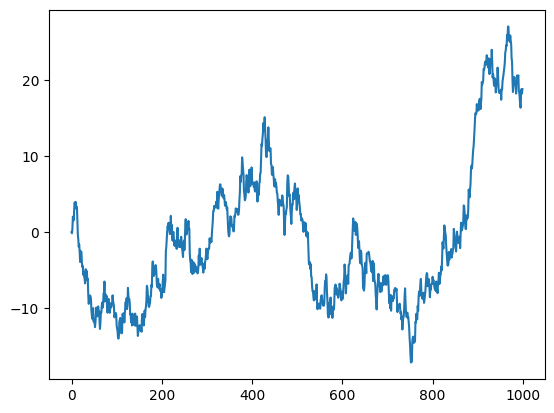

In [5]:
fig, ax = plt.subplots()
ax.plot(random_walk)

stationarity and autocorrelation

constant mean variance and autocorrelation

stationarity

sarima 

stabilizes its mean and variance, thus making it stationary.

differencing

yt' = yt - yt-1

stabilizing the mean porq?

inverse transform

la señal se transforma

log 10 (x) = x'

x'¹⁰ = x


$y_t$ = C + a $y_{t-1}$ + $e_t$

In [6]:
def simulate_process(is_stationary:bool) -> np.array:
    np.random.seed(42)
    
    process = np.empty(400)

    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        alpha = 1.0
        process[0] = 10
    
    for i in range(400):
        if i+1 < 400:
            process[i+1] = alpha * process[i] + np.random.standard_normal()
        else:
            break
    
    return process

stationary = simulate_process(is_stationary=True)
non_stationary = simulate_process(is_stationary=False)




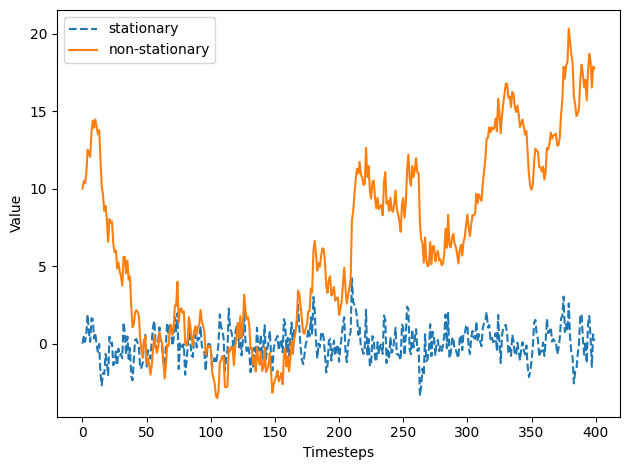

In [7]:
fig, ax = plt.subplots()

ax.plot(stationary, linestyle='--', label='stationary')
ax.plot(non_stationary, linestyle='-', label='non-stationary')

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

ax.legend(loc=2)

plt.tight_layout()
plt.savefig('original.png',dpi=300)

In [8]:
def mean_over_time(process : np.array) -> np.array:
    mean_func = []
    
    for i in range(1, len(process) + 1):
        mean_func.append(np.mean(process[:i]))

    return mean_func

stationary_mean = mean_over_time(stationary)
non_stationary_mean = mean_over_time(non_stationary)

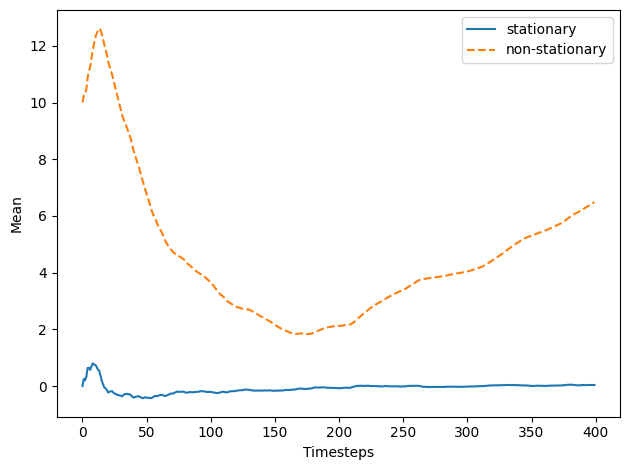

In [9]:
fig, ax = plt.subplots()

ax.plot(stationary_mean, label='stationary')
ax.plot(non_stationary_mean, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Mean')
ax.legend(loc=1)

plt.tight_layout()
plt.savefig('mean.png',dpi=300)

In [10]:
def var_over_time(process : np.array) -> np.array:
    var_func = []
    
    for i in range(1, len(process) + 1):
        
        var_func.append(
            np.var(
                process[:i]
            )
        )

    return var_func

stationary_var = var_over_time(stationary)
non_stationary_var = var_over_time(non_stationary)

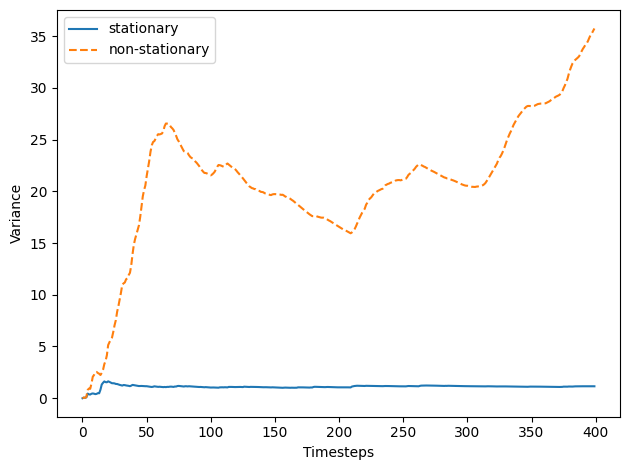

In [11]:
fig, ax = plt.subplots()

ax.plot(stationary_var, label='stationary')
ax.plot(non_stationary_var, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Variance')
ax.legend(loc=2)

plt.tight_layout()
plt.savefig('var.png', dpi=300)

plotting the acf of a stationary process 

can tell us if is a random walk

por eso lo tienes que hacer estacionario, porque no puedes saber si es un random walk

entonces lo transformas hasta que se haga estacionario



In [12]:
ADF_result = adfuller(random_walk)

#ADF statistic is not a large negative number
ADF_result[0]

np.float64(-0.965952487691875)

In [13]:
#p value greater than 0.05
ADF_result[1]

np.float64(0.7654789696692581)

the autocorrelation coefficient is sifnificant if outside shaded area!
it is non stationary

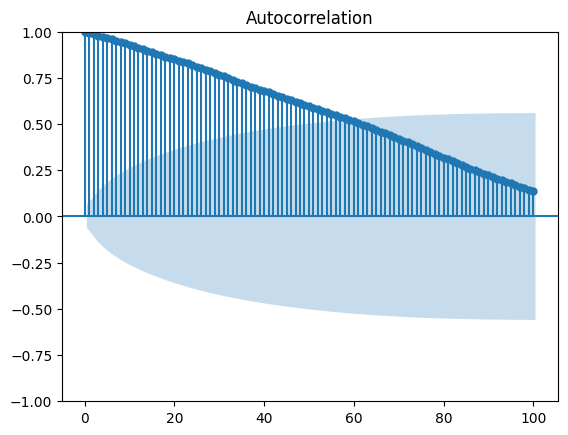

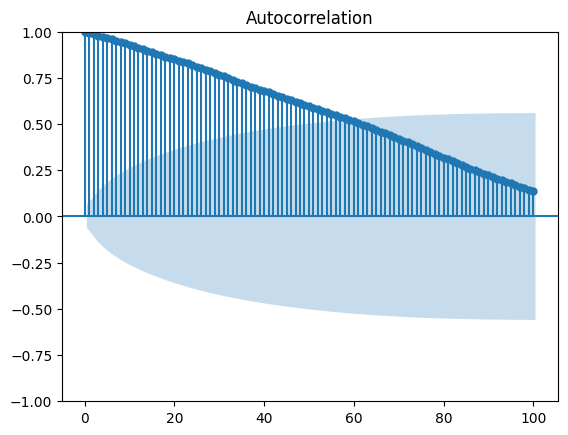

In [14]:
plot_acf(random_walk,lags=100)

In [15]:
diff_random_walk = np.diff(random_walk, n=1)

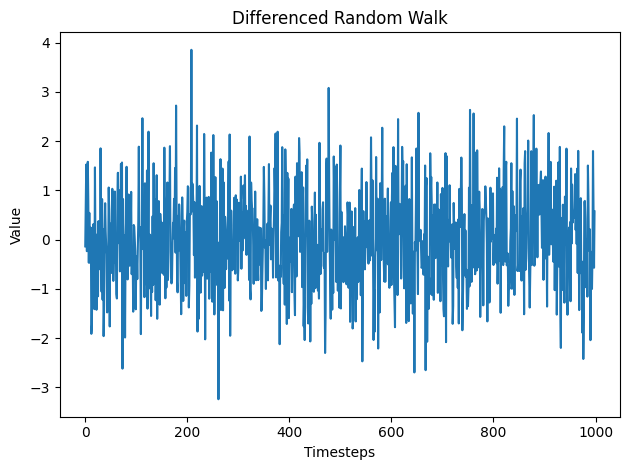

In [16]:
plt.plot(diff_random_walk)
plt.title('Differenced Random Walk')
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig('diff.png', dpi=300)

In [17]:
ADF_result = adfuller(diff_random_walk)
ADF_result[0]

np.float64(-31.789310857560594)

In [18]:
ADF_result[1]

0.0

is stationary
random_walk

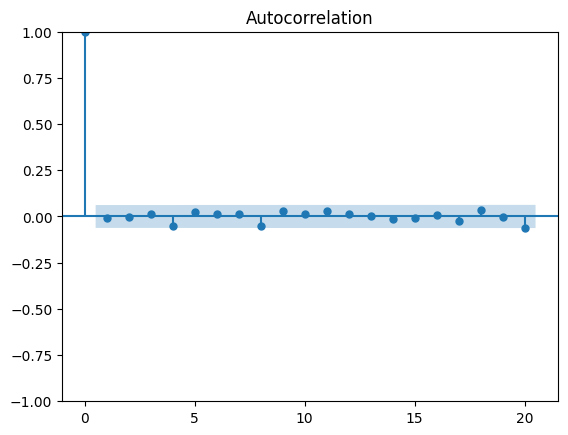

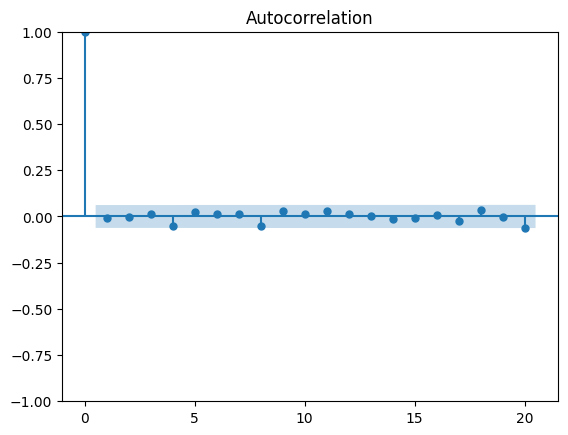

In [19]:
plot_acf(diff_random_walk,lags=20)

In [20]:
df = pd.read_csv('data/GOOGL.csv')

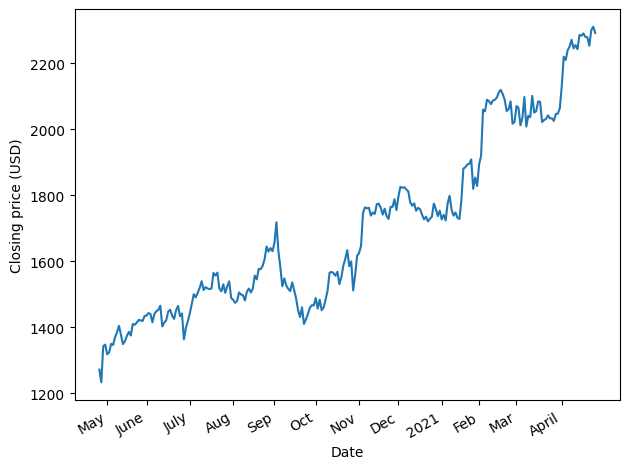

In [21]:
fig, ax = plt.subplots()

ax.plot(df['Date'],df['Close'])

ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235],
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 2021, 'Feb', 'Mar', 'April']
)

fig.autofmt_xdate()
plt.tight_layout()

In [22]:
#if there is a trend there is not a stationary process
#hay una autocorrelacion significativa en el proceso
a = adfuller(df['Close'])

#print(a[0],f"\nP value greater than 0.05 {a[1] > 0.05}")

if a[1] > 0.05:
    print('Non Stationary')
else:
    print('Stationary')
    
#no es estacionaria

Non Stationary


In [23]:
diff_close =  np.diff(df['Close'], n=1)

In [24]:
b = adfuller(diff_close)

#print(b[0],b[1])

if b[1] > 0.05:
    print('Non Stationary')
else:
    print('Stationary')


Stationary


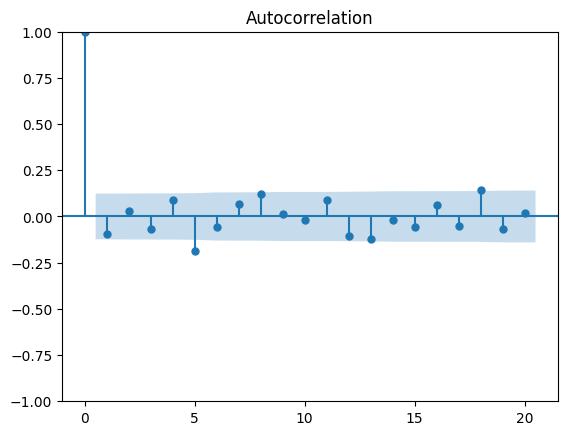

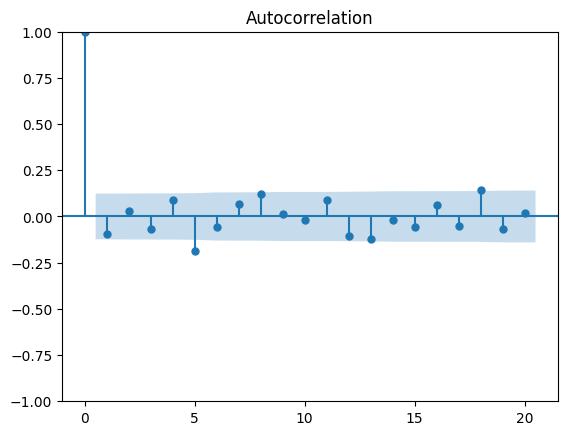

In [25]:
plot_acf(diff_close,lags=20)

In [26]:
#random walk process

In [27]:
df = pd.DataFrame(
    {
        'value':random_walk
    }
)

In [28]:
df.describe()

,value
count,1000.000000
mean,-0.846367
std,9.559968
min,-17.162821
25%,-8.166608
50%,-2.941139
75%,3.864048
max,27.090616


In [29]:
train = df[:800]
test = df[800:]

In [30]:
mean = np.mean(train.value)

In [31]:
test.loc[:,'pred_mean'] = mean

In [32]:
test

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206
...,...,...
995,16.395408,-3.677206
996,18.193095,-3.677206
997,18.833938,-3.677206
998,18.262759,-3.677206


In [33]:
last_value = train[-1:].value.iloc[0]

In [34]:
test.loc[:,'pred_last'] = last_value

In [35]:
test

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947
...,...,...,...
995,16.395408,-3.677206,-6.814947
996,18.193095,-3.677206,-6.814947
997,18.833938,-3.677206,-6.814947
998,18.262759,-3.677206,-6.814947


In [36]:
#slope y la extrapolas

In [37]:
#drift method

In [38]:
drift = (last_value - 0) / (800 - 1)
drift

np.float64(-0.008529346056640632)

In [39]:
x_vals = np.arange(800,1000,1)
x_vals

array([800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812,
       813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825,
       826, 827, 828, 829, 830, 831, 832, 833, 834, 835, 836, 837, 838,
       839, 840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851,
       852, 853, 854, 855, 856, 857, 858, 859, 860, 861, 862, 863, 864,
       865, 866, 867, 868, 869, 870, 871, 872, 873, 874, 875, 876, 877,
       878, 879, 880, 881, 882, 883, 884, 885, 886, 887, 888, 889, 890,
       891, 892, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903,
       904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916,
       917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 928, 929,
       930, 931, 932, 933, 934, 935, 936, 937, 938, 939, 940, 941, 942,
       943, 944, 945, 946, 947, 948, 949, 950, 951, 952, 953, 954, 955,
       956, 957, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968,
       969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 98

In [40]:
pred_drift = drift * x_vals

In [41]:
test

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947
...,...,...,...
995,16.395408,-3.677206,-6.814947
996,18.193095,-3.677206,-6.814947
997,18.833938,-3.677206,-6.814947
998,18.262759,-3.677206,-6.814947


In [42]:
test.loc[:,'pred_drift'] = pred_drift

In [43]:
test

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.823477
801,-6.392708,-3.677206,-6.814947,-6.832006
802,-6.296588,-3.677206,-6.814947,-6.840536
803,-6.758863,-3.677206,-6.814947,-6.849065
804,-7.193359,-3.677206,-6.814947,-6.857594
...,...,...,...,...
995,16.395408,-3.677206,-6.814947,-8.486699
996,18.193095,-3.677206,-6.814947,-8.495229
997,18.833938,-3.677206,-6.814947,-8.503758
998,18.262759,-3.677206,-6.814947,-8.512287


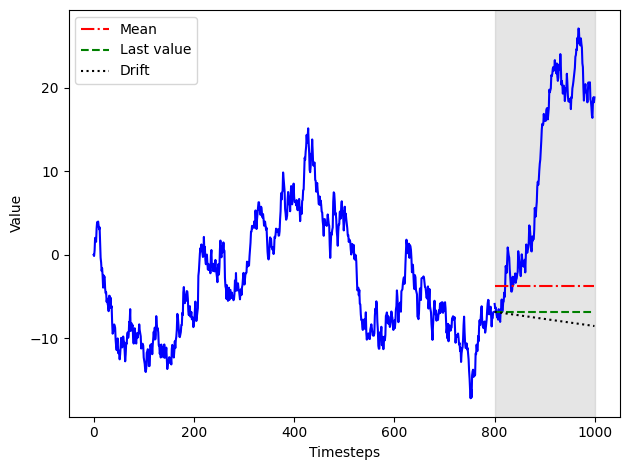

In [44]:
fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')

ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_drift'], 'k:', label='Drift')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

plt.savefig('random_walk_predictions.png',dpi=300)

In [45]:
a = mean_squared_error(test['value'],test['pred_mean'])
b = mean_squared_error(test['value'],test['pred_last'])
c = mean_squared_error(test['value'],test['pred_drift'])

In [46]:
print(a,b,c)
#forecasting long horizon not good!

326.50277395297474 425.1726033055617 465.9076036601397


In [47]:
df.loc[:,'shift'] = df.shift(periods=1).value

In [48]:
df

,value,shift
0,0.000000,NaN
1,-0.138264,0.000000
2,0.509424,-0.138264
3,2.032454,0.509424
4,1.798301,2.032454
...,...,...
995,16.395408,16.676509
996,18.193095,16.395408
997,18.833938,18.193095
998,18.262759,18.833938


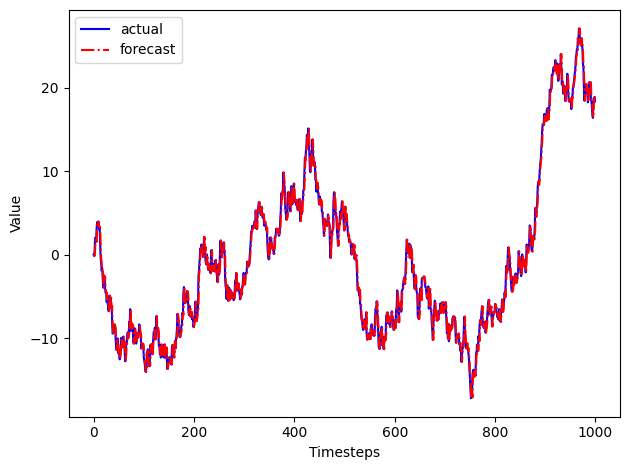

In [49]:
fig, ax = plt.subplots()

ax.plot(df['value'], 'b-', label='actual')
ax.plot(df['shift'], 'r-.', label='forecast')

ax.legend(loc=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

In [55]:
#mean_squared_error()
mean_squared_error(test['value'],df['shift'][800:])

0.9256876651440581